In [1]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import copy
import pickle
import sys
import os
import math

import pytorch_lightning as pl

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

In [12]:
reps = pd.read_csv('..//coles_experiments/supervised_age_bins.csv').drop(columns=['Unnamed: 0'])

In [13]:
reps = reps[reps.dataset == 'test']

In [18]:
reps = reps.iloc[:6, [-1]]
reps['esz'] = eszs

In [23]:
reps.value.values

array([0.556     , 0.56971429, 0.56171429, 0.57171429, 0.56685714,
       0.56428571])

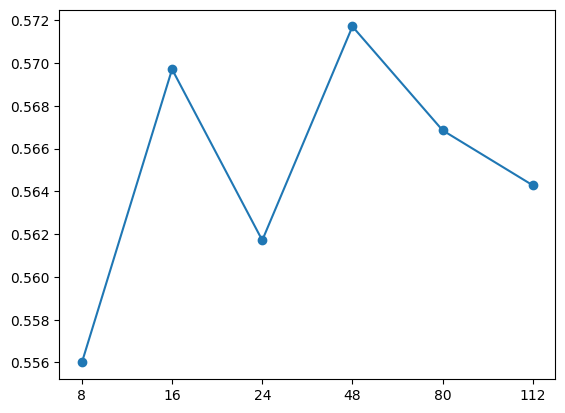

In [21]:
plt.plot(reps.esz.astype(str), reps.value, marker='o')

In [33]:
stats = [
    ('Age-bins Transformer', [0.556, 0.56971429, 0.56171429, 0.57171429, 0.56685714, 0.56428571], [], 'Accuracy score'),
    ('Age-bins CoLES + GB', [], [], 'Accuracy score'),
    ('X5 Transformer', [], [], 'Accuracy score'),
    ('X5 CoLES + GB', [], [], 'Accuracy score'),
    ('Gender Transformer', [], [], 'ROC-AUC score'),
    ('Gender CoLES + GB', [], [], 'ROC-AUC score'),
]

C:\Users\toppc\AppData\Local\Temp\ipykernel_19776\2583626981.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


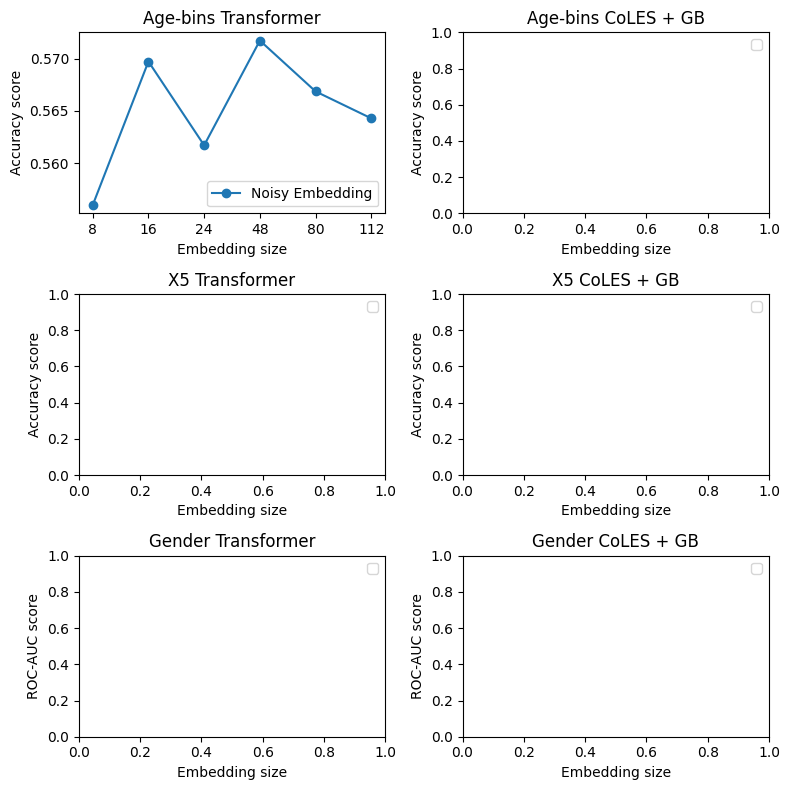

In [36]:
rows = 3
cols = 2
fig, axes = plt.subplots(rows, cols, figsize=(8, 8))
axes = axes.flatten()

eszs = np.array([8, 16, 24, 48, 80, 112]).astype(str)
for ax, st in zip(axes, stats):
    set_name = st[0]
    noisy_y = st[1]
    glove_y = st[2]
    score_type = st[3]

    if noisy_y != []:
        ax.plot(eszs, noisy_y, label=f"Noisy Embedding", marker='o')
    if glove_y != []:
        ax.plot(eszs, glove_y, label=f"Glove Embedding", marker='o')

    ax.set_title(set_name)
    ax.set_xlabel('Embedding size')
    ax.set_ylabel(score_type)
    ax.legend()


plt.tight_layout()
plt.show()
